## WEEK-4: Data Pre-Processing Methods using AutoMPG Dataset

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the AutoMPG dataset from UCI Machine Learning Repository
# The dataset has no header, so we provide column names manually.
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name']
df = pd.read_csv('http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data',
                 delim_whitespace=True, names=column_names)

# Display the first 5 rows of the DataFrame
print("Original DataFrame head:")
display(df.head())

# Display basic information about the DataFrame
print("\nDataFrame Info:")
df.info()

# Display descriptive statistics
print("\nDataFrame Description:")
display(df.describe(include='all'))

/tmp/ipykernel_1341/2373621717.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data',


Original DataFrame head:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB

DataFrame Description:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
count,398.000000,398.000000,398.000000,398,398.000000,398.000000,398.000000,398.000000,398
unique,NaN,NaN,NaN,94,NaN,NaN,NaN,NaN,305
top,NaN,NaN,NaN,150.0,NaN,NaN,NaN,NaN,ford pinto
freq,NaN,NaN,NaN,22,NaN,NaN,NaN,NaN,6
mean,23.514573,5.454774,193.425879,NaN,2970.424623,15.568090,76.010050,1.572864,NaN
std,7.815984,1.701004,104.269838,NaN,846.841774,2.757689,3.697627,0.802055,NaN
min,9.000000,3.000000,68.000000,NaN,1613.000000,8.000000,70.000000,1.000000,NaN
25%,17.500000,4.000000,104.250000,NaN,2223.750000,13.825000,73.000000,1.000000,NaN
50%,23.000000,4.000000,148.500000,NaN,2803.500000,15.500000,76.000000,1.000000,NaN
75%,29.000000,8.000000,262.000000,NaN,3608.000000,17.175000,79.000000,2.000000,NaN


### 1. Removing Outliers / Missing Values

First, let's address the missing values. The `horsepower` column is noted to have '?' values, which are not recognized as NaN by default. We need to convert these to NaN and then handle them.

In [2]:
# Convert 'horsepower' to numeric, coercing errors will turn '?' into NaN
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Check for missing values after conversion
print("Missing values after converting 'horsepower':")
display(df.isnull().sum())

# For simplicity, let's drop rows with any missing values for this exercise.
# In a real scenario, you might impute them, which we will demonstrate later.
df_cleaned = df.dropna().copy()

print("\nDataFrame head after dropping rows with missing values:")
display(df_cleaned.head())
print(f"Original shape: {df.shape}, Shape after dropping missing values: {df_cleaned.shape}")

Missing values after converting 'horsepower':


,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0



DataFrame head after dropping rows with missing values:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


Original shape: (398, 9), Shape after dropping missing values: (392, 9)


Next, let's identify and remove outliers using the Interquartile Range (IQR) method for numerical columns. We'll focus on `mpg`, `displacement`, `horsepower`, `weight`, and `acceleration`.

Removed 0 outliers from 'mpg' (current shape: (392, 9))
Removed 0 outliers from 'displacement' (current shape: (392, 9))
Removed 10 outliers from 'horsepower' (current shape: (382, 9))
Removed 0 outliers from 'weight' (current shape: (382, 9))
Removed 9 outliers from 'acceleration' (current shape: (373, 9))

DataFrame head after outlier removal:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


Shape after outlier removal: (373, 9)


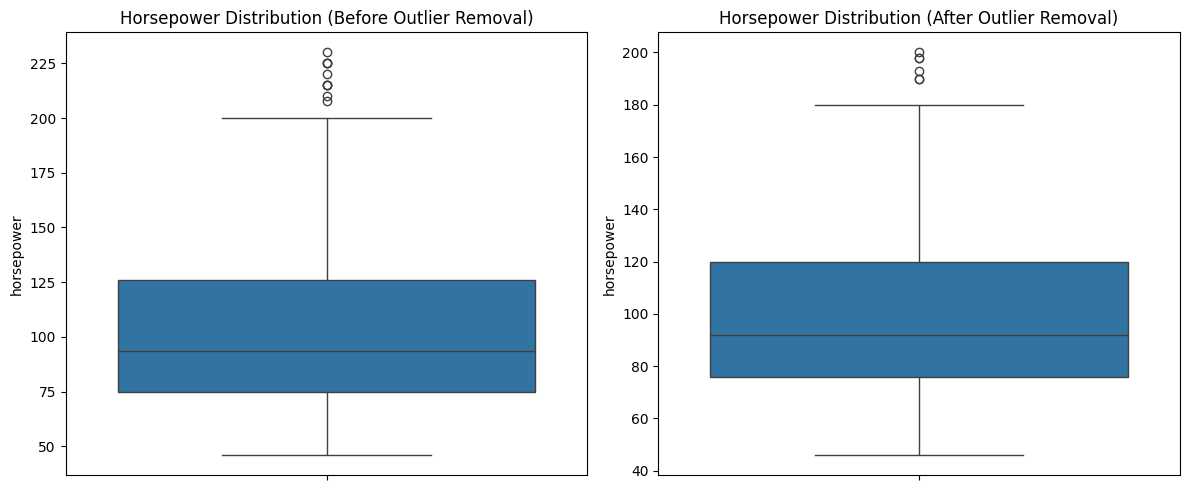

In [3]:
# Function to remove outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_no_outliers = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_no_outliers

# Apply outlier removal to key numerical columns
columns_for_outliers = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

df_no_outliers = df_cleaned.copy()
for col in columns_for_outliers:
    initial_shape = df_no_outliers.shape[0]
    df_no_outliers = remove_outliers_iqr(df_no_outliers, col)
    removed_count = initial_shape - df_no_outliers.shape[0]
    print(f"Removed {removed_count} outliers from '{col}' (current shape: {df_no_outliers.shape})")

print("\nDataFrame head after outlier removal:")
display(df_no_outliers.head())
print(f"Shape after outlier removal: {df_no_outliers.shape}")

# Visualize distributions before and after outlier removal for one column (e.g., horsepower)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_cleaned['horsepower'])
plt.title('Horsepower Distribution (Before Outlier Removal)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_no_outliers['horsepower'])
plt.title('Horsepower Distribution (After Outlier Removal)')

plt.tight_layout()
plt.show()

### 2. Imputing Standard Values

Even though we dropped missing values earlier, let's demonstrate imputation by re-introducing missing values to a copy of the original DataFrame and then filling them. We will impute missing `horsepower` values with the median of the `horsepower` column.

In [4]:
# Create a fresh copy of the original DataFrame (before dropping missing values and outliers)
df_impute = df.copy()

# Convert 'horsepower' to numeric, turning '?' into NaN
df_impute['horsepower'] = pd.to_numeric(df_impute['horsepower'], errors='coerce')

print("Missing values before imputation:")
display(df_impute.isnull().sum())

# Calculate the median of the 'horsepower' column
median_horsepower = df_impute['horsepower'].median()

# Impute missing 'horsepower' values with the median
df_impute['horsepower'].fillna(median_horsepower, inplace=True)

print("\nMissing values after median imputation:")
display(df_impute.isnull().sum())

print("\nDataFrame head after median imputation for 'horsepower':")
display(df_impute.head())
print(f"Shape after imputation: {df_impute.shape}")

Missing values before imputation:


,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0



Missing values after median imputation:


/tmp/ipykernel_1341/1187525686.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_impute['horsepower'].fillna(median_horsepower, inplace=True)


,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
car_name,0



DataFrame head after median imputation for 'horsepower':


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


Shape after imputation: (398, 9)


### 3. Capping of Values

Capping, also known as winsorization, limits extreme values in a dataset. We will cap the `weight` column of the `df_no_outliers` DataFrame at the 1st and 99th percentiles to demonstrate this technique.

1st percentile of weight: 1769.36
99th percentile of weight: 4918.88

DataFrame head after capping 'weight' values:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino



Min weight after capping: 1769.36
Max weight after capping: 4918.88


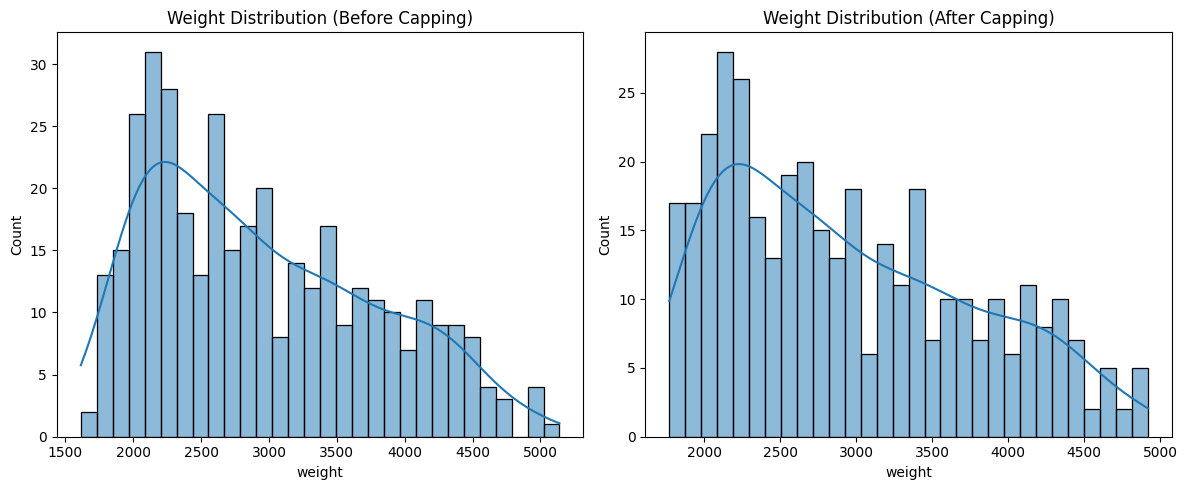

In [5]:
# Create a copy of the DataFrame that had outliers removed earlier
df_capped = df_no_outliers.copy()

# Calculate the 1st and 99th percentiles for the 'weight' column
lower_bound_weight = df_capped['weight'].quantile(0.01)
upper_bound_weight = df_capped['weight'].quantile(0.99)

print(f"1st percentile of weight: {lower_bound_weight:.2f}")
print(f"99th percentile of weight: {upper_bound_weight:.2f}")

# Cap the 'weight' column
df_capped['weight'] = np.where(df_capped['weight'] < lower_bound_weight, lower_bound_weight, df_capped['weight'])
df_capped['weight'] = np.where(df_capped['weight'] > upper_bound_weight, upper_bound_weight, df_capped['weight'])

print("\nDataFrame head after capping 'weight' values:")
display(df_capped.head())

# Check if min/max values are within the capped range
print(f"\nMin weight after capping: {df_capped['weight'].min():.2f}")
print(f"Max weight after capping: {df_capped['weight'].max():.2f}")

# Visualize distribution before and after capping
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_no_outliers['weight'], bins=30, kde=True)
plt.title('Weight Distribution (Before Capping)')

plt.subplot(1, 2, 2)
sns.histplot(df_capped['weight'], bins=30, kde=True)
plt.title('Weight Distribution (After Capping)')

plt.tight_layout()
plt.show()